# Analysis for fragment linking

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from plotly import express as px
from tqdm import tqdm

In [2]:
from tools import (
    compute_uniqueness,
    compute_novelty,
    compute_unique_novelty,
)

## Load data

In [3]:
# load individually evaluation files

files = {
    "ground truth linker": "data/conditional_fragments/reference_mols_named.csv",
    "link replacement": "predictions/conditional_fragments/attempt_2/link_replacment.csv",
    "link replacement no h": "predictions/conditional_fragments/attempt_2/link_replacment_no_h.csv",
}

dfs = []
for method, file in files.items():
    print(f"Loading {method}")
    df = pd.read_csv(file, low_memory=False)
    # Evaluation script does not break molecules correctly, introducting these rows
    # df = df[~df.fail.fillna(0).astype(bool)].reset_index(drop=True)
    df = df.drop(columns=["index", "fail"], errors="ignore")

    df_frag = pd.read_csv(
        Path(file).parent / (Path(file).stem + "_combined.csv"),
        low_memory=False,
    ).reset_index()
    df_frag.columns = [c.lower().replace(" ", "_") for c in df_frag.columns]
    df_frag = df_frag.drop(columns=["index", "fail", "error"])

    if len(df) != len(df_frag):
        print(f"Lengths are not equal: {len(df)} != {len(df_frag)}")
        continue
    df = pd.concat([df, df_frag], axis=1, ignore_index=False)
    df["method"] = method

    if method == "ground truth linker":
        df = df[:1000]  # only used the first 1000 linkers

    dfs.append(df)

df = pd.concat(dfs, ignore_index=True)

df["total_number"] = True
df["valid"] = df["connected"] & df["chemical"] & df["physical"]

df["num_atoms_missing"] = df["num_atoms_link"] - df["num_atoms_frag"]
df["share_atoms_frag"] = df["num_atoms_frag"] / df["num_atoms_link"]
df["share_atom_missing"] = df["num_atoms_missing"] / df["num_atoms_link"]

Loading ground truth linker
Loading link replacement
Loading link replacement no h


In [4]:
file = "/homes/buttensc/Projects/semla-flow/data/conditional_fragments/reference_mols.csv"
truth = pd.read_csv(file)
truth = truth[truth.fail != 1.0]
print(len(truth))

1129


In [5]:
reference_smiles = set(truth["smiles"])
print(len(reference_smiles))

179


In [6]:
# enrichment
df["total_number"] = True
df["valid"] = df["connected"] & df["chemical"] & df["physical"]
df["novel"] = df["smiles"].map(lambda x: x not in reference_smiles)
df["valid_novel"] = df["valid"] & df["novel"]
df["valid_smiles"] = df["valid"].astype(bool) * df["smiles"]
df["valid_scaffold_rdkit_csk"] = df["valid"].astype(bool) & df["scaffold_rdkit_csk"].astype(bool)
df["valid_scaffold_hop_smiles"] = (~df["valid_scaffold_rdkit_csk"]) * df["valid_smiles"]

In [7]:
# rename methods and define order of methods
names = {
    "ground truth linker": "Ground truth linker",
    "link replacement": "Link replacement (with H)",
    "link replacement no h": "Link replacement (no H)",
}
df["method"] = pd.Categorical(df["method"].map(names), categories=names.values(), ordered=True)

In [35]:
# filter
metrics = [
    "esp_sim_frag",
    "esp_sim_link",
    "shape_tanimoto_frag",
    "shape_tanimoto_link",
    "ecfp4_bit_tanimoto_frag",
    "ecfp4_bit_tanimoto_link",
    "shape_protrusion_frag_1",
    "shape_protrusion_frag_2",
    "shape_protrusion_link_1",
    "shape_protrusion_link_2",
    "feat_map_score_frag_1",
    "feat_map_score_frag_2",
    "feat_map_score_link_1",
    "feat_map_score_link_2",
    "sucos_frag_1",
    "sucos_frag_2",
    "sucos_link_1",
    "sucos_link_2",
]

aggs = {metric: (metric, "max") for metric in metrics}
df_best = (
    df[(df.valid & df.novel) | ((df.method == "ground truth linker") & df.valid)]
    .groupby(["method", "reference_molecule", "smiles"], observed=True)
    .agg(**aggs)
    .reset_index()
)

## Tables

In [36]:
def wrap_envs(latex: str, envs: list[str] = ["center", "small", "sc"]) -> str:
    for env in envs:
        latex = latex.replace(r"\begin{tabular}", r"\begin{" + env + "}" + "\n" + r"\begin{tabular}")
        latex = latex.replace(r"\end{tabular}", r"\end{tabular}" + "\n" + r"\end{" + env + "}")
    return latex


In [37]:
df.columns

Index(['connected', 'chemical', 'physical', 'ensemble_avg_energy',
       'mol_pred_energy', 'energy_ratio', 'name', 'sa', 'sa_normalized',
       'spacial', 'qed', 'logp', 'lipinski', 'num_heavy', 'weight',
       'num_rings', 'smiles', 'error', 'tanimoto_frag', 'tanimoto_link',
       'sucos_frag', 'sucos_link', 'scaffold_true_csk', 'scaffold_rdkit_csk',
       'smiles_pred', 'smiles_link', 'num_atoms_pred', 'num_atoms_frag',
       'num_atoms_link', 'reference_molecule', 'method', 'esp_sim_frag',
       'esp_sim_link', 'shape_tanimoto_frag', 'shape_tanimoto_link',
       'ecfp4_bit_tanimoto_frag', 'ecfp4_bit_tanimoto_link',
       'shape_protrusion_frag_1', 'shape_protrusion_frag_2',
       'shape_protrusion_link_1', 'shape_protrusion_link_2',
       'feat_map_score_frag_1', 'feat_map_score_frag_2',
       'feat_map_score_link_1', 'feat_map_score_link_2', 'sucos_frag_1',
       'sucos_frag_2', 'sucos_link_1', 'sucos_link_2', 'scaffold_pred',
       'scaffold_link', 'scaffold_conserv

### Validity

In [38]:
def mean(x):
    n = 100000
    if len(x) == 0:
        return float("nan")
    if len(x) > 2000:
        return np.sum(x) / n
    return np.sum(x) / 1127


def std(x):
    n = 100000
    if len(x) == 0:
        return float("nan")
    if len(x) > n:
        return np.std(x)
    m = np.sum(x) / n
    return np.sqrt(np.sum((x - m) ** 2) / n)


aggs = {
    "Total number": ("total_number", "sum"),
    r"Generated \unit{\percent}": ("total_number", mean),
    r"Connected \unit{\percent}": ("connected", mean),
    r"Chemical \unit{\percent}": ("chemical", mean),
    r"Physical \unit{\percent}": ("physical", mean),
    r"Valid \unit{\percent}": ("valid", mean),
    # "valid_scaffold_hop": ("scaffold_rdkit_csk", 1 - mean),
}
df_agg = df.groupby(["method"], observed=False).agg(**aggs)
df_agg.iloc[0, 1] = pd.NA
cols = df_agg.columns
df_agg.index.name = None
cols = df_agg.columns
df_style = df_agg.style.format("{:.0f}", subset=cols[:1]).format("{:.1%}", subset=cols[1:])
df_style

,Total number,Generated \unit{\percent},Connected \unit{\percent},Chemical \unit{\percent},Physical \unit{\percent},Valid \unit{\percent}
Ground truth linker,1000,nan%,88.6%,88.1%,83.5%,83.0%
Link replacement (with H),73154,73.2%,58.1%,73.1%,61.5%,49.9%
Link replacement (no H),80281,80.3%,73.6%,80.3%,70.3%,64.7%


In [39]:
caption = """
Validity of the on linker fragments conditioned generated molecules.
The table contains the total number of molecules that was to be generated and the proportions of molecules requiring connectedness, chemical validity, physical validity, and overall validity.
As defined in the method, a molecule with a conformation is valid only if it is connected, chemically valid, and physically valid.
"""
label = "tab:cond_frags_validity"
latex = df_style.to_latex(
    label=label,
    siunitx=True,
    environment="table*",
    hrules=True,
    caption=caption,
    sparse_columns=False,
)
latex = latex.replace("%", "").replace("nan", "")
latex = wrap_envs(latex, ["center"])
with open("tables/cond_frags_validity.tex", "w") as f:
    f.write(latex)

### Properties

In [40]:
df_filter = df[df.valid]
aggs = {
    "qed": ["mean", "std"],
    "sa": ["mean", "std"],
    "energy_ratio": ["mean", "std"],
    "weight": ["mean", "std"],
    "num_heavy": ["mean", "std"],
    "num_rings": ["mean", "std"],
    "lipinski": ["mean", "std"],
    "logp": ["mean", "std"],
    "spacial": ["mean", "std"],
}
df_agg = df_filter.groupby(["method"], observed=False).agg(aggs)
cols = df_agg.columns
df_agg.style.format("{:.2f}", subset=cols)

### Energy ratio

In [41]:
df_filter = df[df.valid]
df_filter = df
aggs = {
    "ensemble_avg_energy": ["mean", "std"],
    "mol_pred_energy": ["mean", "std"],
    "energy_ratio": ["mean", "std"],
}
df_agg = df_filter.groupby(["method"], observed=False).agg(aggs)
cols = df_agg.columns
df_agg.style.format("{:.2f}", subset=cols)

### Unique, novel, useful

In [42]:
n = 100000

df_filter = df
aggs = {
    "Valid": ("valid", lambda x: sum(x) / n if len(x) > 2000 else sum(x) / 1127),
    # "Valid & Scaffold Hop": ("scaffold_rdkit_csk", lambda x: 1 - mean(x)),
    # "Valid & Unique": (
    #     "valid_smiles",
    #     lambda x: compute_uniqueness(x, total=1) / n,
    # ),
    # "Valid & Novel": (
    #     "valid_smiles",
    #     lambda x: compute_novelty(x, reference_smiles, total=1) / n,
    # ),
    "Valid \& Unique \& Novel": (
        "valid_smiles",
        lambda x: compute_unique_novelty(x, reference_smiles, total=1) / n
        if len(x) > 2000
        else compute_unique_novelty(x, reference_smiles, total=1) / 1127,
    ),
    "Valid \& Unique \& Novel \& Scaffold Hop": (
        "valid_scaffold_hop_smiles",
        lambda x: compute_unique_novelty(x, reference_smiles, total=1) / n
        if len(x) > 2000
        else compute_unique_novelty(x, reference_smiles, total=1) / 1127,
    ),
}
df_agg = df_filter.groupby(["method"], observed=False).agg(**aggs)
cols = df_agg.columns
df_style = df_agg.style.format("{:.2%}")
df_style

,Valid,Valid \& Unique \& Novel,Valid \& Unique \& Novel \& Scaffold Hop
method,,,
Ground truth linker,82.96%,0.62%,0.62%
Link replacement (with H),49.94%,45.86%,0.04%
Link replacement (no H),64.71%,64.67%,0.02%


In [43]:
caption = """
Validity, uniqueness, novelty, and share of scaffold hops for the on linker fragments conditioned generated molecules.
These are proportions of the total number of molecules that were to be generated.
"""
label = "tab:cond_frags_novelty"
latex = df_style.to_latex(
    label=label,
    siunitx=True,
    environment="table*",
    hrules=True,
    caption=caption,
    sparse_columns=False,
)
latex = latex.replace("%", "").replace("nan", "")
latex = wrap_envs(latex, ["center"])
with open("tables/cond_frags_novelty.tex", "w") as f:
    f.write(latex)

### Quality

In [44]:
df_filter = df[df.valid]
df_filter = df
aggs = {
    "sucos_frag mean": ("sucos_frag", "mean"),
    "sucos_frag std": ("sucos_frag", "std"),
    "sucos_frag > 0.8 ": ("sucos_frag", lambda x: sum(x > 0.8) / n),
    "sucos_link mean": ("sucos_link", "mean"),
    "sucos_link std": ("sucos_link", "std"),
    "sucos_link > 0.55 ": ("sucos_link", lambda x: sum(x > 0.55) / n),
}
df_agg = df_filter.groupby(["method"], observed=False).agg(**aggs)
# df_agg["tanimoto > 0.8 and sucos > 0.55"] = (
#     df_agg["sucos > 0.55 "] * df_agg["tanimoto > 0.8 "]
# )
cols = df_agg.columns
df_agg.style.format("{:.2%}", subset=cols)

,sucos_frag mean,sucos_frag std,sucos_frag > 0.8,sucos_link mean,sucos_link std,sucos_link > 0.55
method,,,,,,
Ground truth linker,95.93%,6.31%,0.96%,100.00%,0.00%,0.99%
Link replacement (with H),nan%,nan%,0.00%,nan%,nan%,0.00%
Link replacement (no H),nan%,nan%,0.00%,nan%,nan%,0.00%


# Usefulness

In [49]:
# How many unique new linkers capitulate the fragments and have SuCOS larger than x?
metric_1 = "sucos_frag_1"
metric_2 = "sucos_link_1"

# How many good new linkers were created?
threshold_link = 0.7
threshold_frag = 0.7
aggs = {
    f"{metric_1} > {threshold_frag}": (metric_1, lambda x: sum(x > threshold_frag) > 0),
    f"{metric_2} > {threshold_link}": (metric_2, lambda x: sum(x > threshold_link) > 0),
}
df_agg = df_best.groupby(["method", "reference_molecule"], observed=True).agg(**aggs)
df_agg[f"{metric_2} > {threshold_link} and {metric_1} > {threshold_frag}"] = (
    df_agg[f"{metric_2} > {threshold_link}"] * df_agg[f"{metric_1} > {threshold_frag}"]
)
print("number of reference molecules new linkers were created for")
df_agg.groupby(["method"], observed=True).sum()
# df_agg

number of reference molecules new linkers were created for


,sucos_frag_1 > 0.7,sucos_link_1 > 0.7,sucos_link_1 > 0.7 and sucos_frag_1 > 0.7
method,,,
Link replacement (with H),854,504,496
Link replacement (no H),703,323,311


## Plots

In [50]:
df_best

,method,reference_molecule,smiles,esp_sim_frag,esp_sim_link,shape_tanimoto_frag,shape_tanimoto_link,ecfp4_bit_tanimoto_frag,ecfp4_bit_tanimoto_link,shape_protrusion_frag_1,...,shape_protrusion_link_1,shape_protrusion_link_2,feat_map_score_frag_1,feat_map_score_frag_2,feat_map_score_link_1,feat_map_score_link_2,sucos_frag_1,sucos_frag_2,sucos_link_1,sucos_link_2
0,Link replacement (with H),reference_0,C#CCOc1ccc(C(=NNC2CCCC2)C(=O)c2ccc(OC)o2)cc1OC,0.803210,0.749580,0.684895,0.661031,0.339450,0.557692,0.765335,...,0.817805,0.776807,0.731173,0.731173,0.632975,0.619986,0.800076,0.748254,0.704891,0.718896
1,Link replacement (with H),reference_0,CCOc1cc(S(=O)(=O)C(=CC(=O)NC2CCCC2)c2cccs2)ccc1OC,0.625983,0.625187,0.638864,0.656616,0.304348,0.349593,0.730286,...,0.809770,0.775799,0.428249,0.428249,0.420973,0.417723,0.630693,0.579267,0.598386,0.613747
2,Link replacement (with H),reference_0,CCOc1ccc(C(=O)N[C@@H](C(=O)NC2CCCC2)c2cccs2)cc1OC,0.603932,0.606884,0.622779,0.590994,0.390476,0.528302,0.730927,...,0.774189,0.717144,0.431230,0.431230,0.376507,0.376507,0.621036,0.581079,0.546826,0.575348
3,Link replacement (with H),reference_0,CCOc1ccc(C(=O)[C@@H](Sc2cccs2)C(=O)NC2CCCC2)cc1OC,0.699945,0.675492,0.672094,0.689554,0.313043,0.415254,0.723867,...,0.795556,0.833805,0.751373,0.751373,0.631035,0.605128,0.827522,0.737620,0.732420,0.700342
4,Link replacement (with H),reference_0,CCOc1ccc(S(=O)(=O)N(C(=O)NC2CCCC2)c2cccs2)cc1C...,0.341350,0.367157,0.748889,0.743019,0.490000,0.309524,0.790780,...,0.853070,0.848672,0.812691,0.812691,0.629608,0.629608,0.876506,0.801736,0.739140,0.741339
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
110222,Link replacement (no H),reference_999,O=C([C@H](Nc1ccc(F)cc1)c1ccccc1)N1CCN(S(=O)(=O...,0.136826,0.477945,0.556475,0.578577,0.224806,0.264286,0.653342,...,0.728275,0.733999,0.457781,0.471718,0.407285,0.398538,0.623435,0.562530,0.570642,0.563406
110223,Link replacement (no H),reference_999,O=C1CCN2CC[C@@](c3ccns3)(C2=O)[C@H](c2ccccc2)C...,0.639297,0.505579,0.544990,0.589418,0.202899,0.225166,0.634911,...,0.727100,0.755123,0.640791,0.640791,0.467775,0.464660,0.716865,0.637851,0.611449,0.595880
110224,Link replacement (no H),reference_999,O=C1C[C@@H]2CC[C@H]([C@](O)(c3cccnc3)c3cccs3)C...,0.503497,0.472837,0.606733,0.648291,0.265152,0.328571,0.681888,...,0.774495,0.800845,0.540863,0.516081,0.409311,0.387616,0.692905,0.598985,0.605078,0.581055
110225,Link replacement (no H),reference_999,O=C1C[C@](C(=O)N[C@H]2CCOC2)(c2ccc[nH]2)[C@H](...,0.334614,0.267147,0.517201,0.524768,0.178571,0.277778,0.615688,...,0.678398,0.698267,0.357159,0.357159,0.296951,0.296951,0.559539,0.486424,0.497609,0.487675


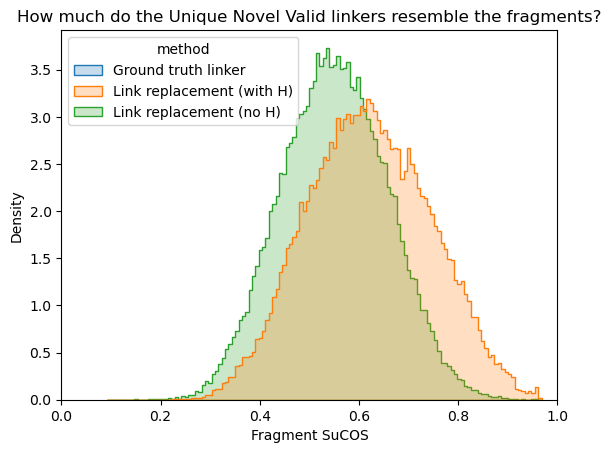

In [54]:
metric = "sucos_frag_1"
fig = sns.histplot(
    df_best[df_best.method != "ground truth linker"].groupby(["method", "smiles"], observed=True).agg({metric: "max"}),
    x=metric,
    hue="method",
    # complementary=True,
    common_norm=False,
    # stat="count",
    stat="density",
    element="step",
    # fill=False,
    # bins=50,
    # legend=True, palette="tab10", linewidth=1.5
)
fig.set(
    xlim=(0, 1),
    # ylim=(0, 1400),
    title="How much do the Unique Novel Valid linkers resemble the fragments?",
    xlabel="Fragment SuCOS",
)
plt.savefig("plots/conditional_frags_comparison_to_fragments.png")

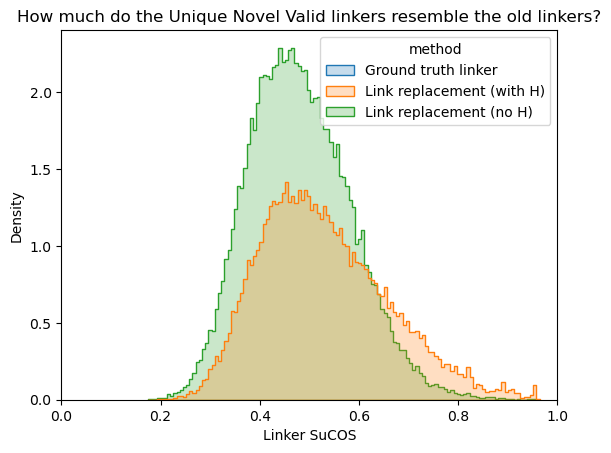

In [57]:
metric = "sucos_link_1"

fig = sns.histplot(
    df_best[df_best.method != "ground truth linker"].groupby(["method", "smiles"], observed=True).agg({metric: "max"}),
    x=metric,
    hue="method",
    # complementary=True,
    # common_norm=False,
    # stat="count",
    stat="density",
    element="step",
    # fill=False,
    # bins=50,
    # legend=True, palette="tab10", linewidth=1.5
)
fig.set(
    xlim=(0, 1),
    # ylim=(0, 1400),
    title="How much do the Unique Novel Valid linkers resemble the old linkers?",
    xlabel="Linker SuCOS",
)
plt.savefig("plots/conditional_frags_comparison_to_linker.png")

## Basic metrics

In [22]:
metrics = {
    "ensemble_avg_energy": "Ensemble Average Energy",
    "mol_pred_energy": "Molecular Prediction Energy",
    "energy_ratio": "Energy Ratio",
    "sa": "Synthetic Accessability Score",
    "sa_normalized": "Synthetic Accessability Score (normalized)",
    "spacial": "Spacial Score",
    "qed": "Quantitative Estimation of Drug-likeness",
    "logp": "LogP",
    "lipinski": "Lipinski Rule of 5",
    "num_heavy": "Number of Heavy Atoms",
    "weight": "Molecular Weight",
    "num_rings": "Number of Rings",
}

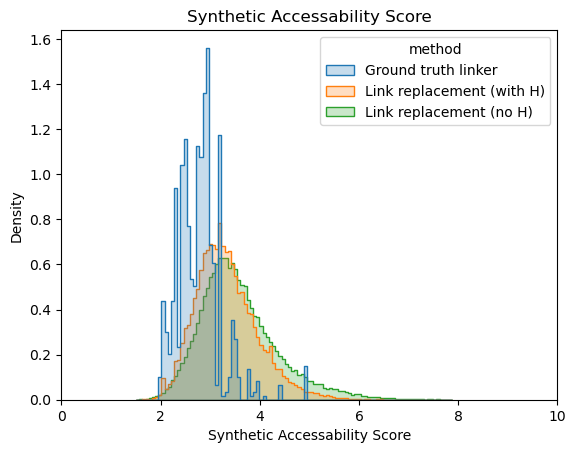

In [23]:
metric = "sa"
name = metrics[metric]
sns.histplot(
    df[df.valid][["method", metric]].reset_index(drop=True),
    x=metric,
    hue="method",
    bins=100,
    cumulative=False,
    common_norm=False,
    stat="density",
    element="step",
    # legend=True, palette="tab10", linewidth=1.5
)
plt.title(name)
plt.xlabel(name)
plt.xlim(0, 10)
plt.savefig(f"plots/conditional_frags_{metric}.png")

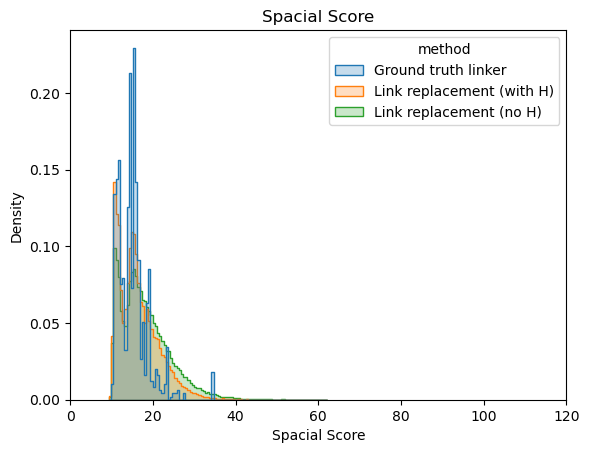

In [24]:
metric = "spacial"
name = metrics[metric]
sns.histplot(
    df[df.valid][["method", metric]].reset_index(drop=True),
    x=metric,
    hue="method",
    bins=100,
    cumulative=False,
    common_norm=False,
    stat="density",
    element="step",
    # legend=True, palette="tab10", linewidth=1.5
)
plt.title(name)
plt.xlabel(name)
plt.xlim(0, 120)
plt.savefig(f"plots/conditional_frags_{metric}.png")

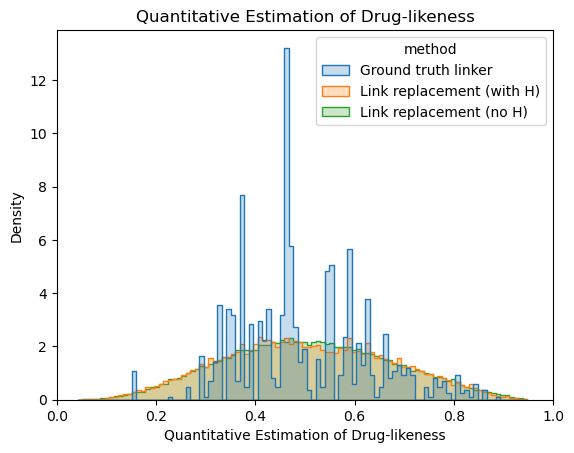

In [25]:
metric = "qed"
name = metrics[metric]
sns.histplot(
    df[df.valid][["method", metric]].reset_index(drop=True),
    x=metric,
    hue="method",
    bins=100,
    cumulative=False,
    common_norm=False,
    stat="density",
    element="step",
    # legend=True, palette="tab10", linewidth=1.5
)
plt.title(name)
plt.xlabel(name)
plt.xlim(0, 1)
plt.savefig(f"plots/conditional_frags_{metric}.png")

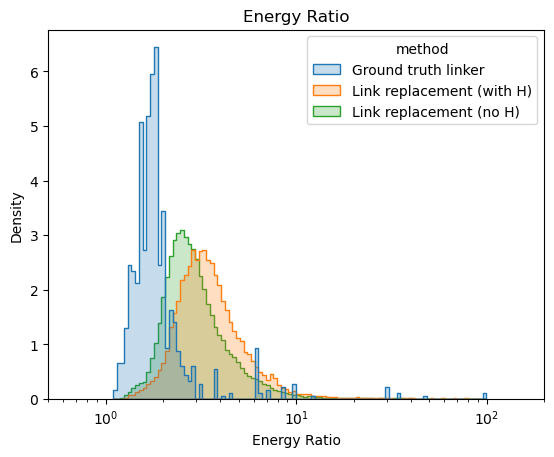

In [26]:
metric = "energy_ratio"
name = metrics[metric]
sns.histplot(
    df[df.valid][["method", metric]].reset_index(drop=True),
    x=metric,
    bins=100,
    hue="method",
    cumulative=False,
    common_norm=False,
    stat="density",
    element="step",
    log_scale=True if metric == "energy_ratio" else False,
    # legend=True, palette="tab10", linewidth=1.5
)
plt.title(name)
plt.xlabel(name)
plt.xlim(0.5, 200)
plt.savefig(f"plots/conditional_frags_{metric}.png")

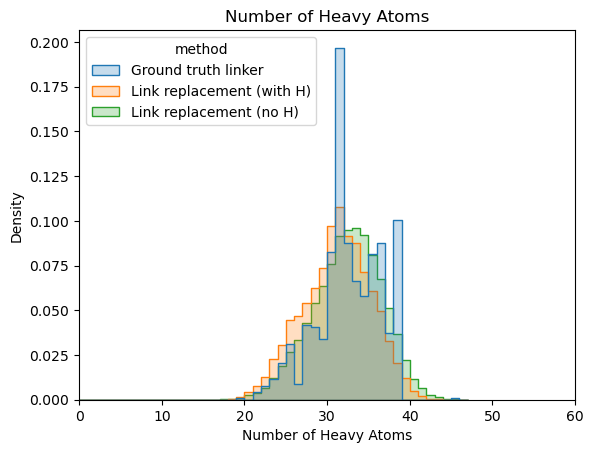

In [27]:
metric = "num_heavy"
name = metrics[metric]
sns.histplot(
    df[df.valid][["method", metric]].reset_index(drop=True),
    x=metric,
    bins=np.array(range(int(df[df.valid]["num_heavy"].max()) + 1)),
    hue="method",
    cumulative=False,
    common_norm=False,
    stat="density",
    element="step",
    fill=True,
    # legend=True, palette="tab10", linewidth=1.5
)
plt.title(name)
plt.xlabel(name)
plt.xlim(0, 60)
plt.savefig(f"plots/conditional_frags_{metric}.png")

# Appendix

## Old plots

<Axes: xlabel='tanimoto_frag', ylabel='Count'>

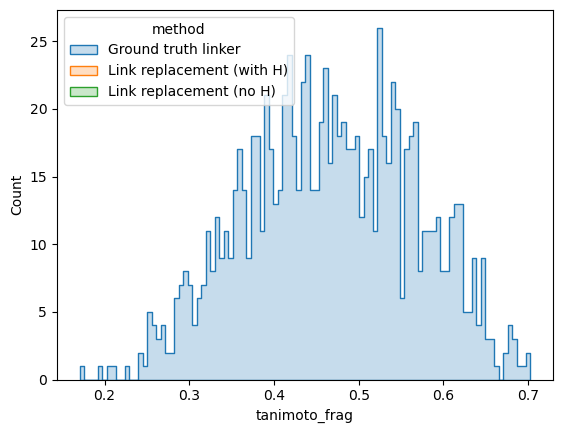

In [28]:
sns.histplot(df, x="tanimoto_frag", hue="method", element="step", common_norm=False, bins=100)

<Axes: xlabel='tanimoto_link', ylabel='Count'>

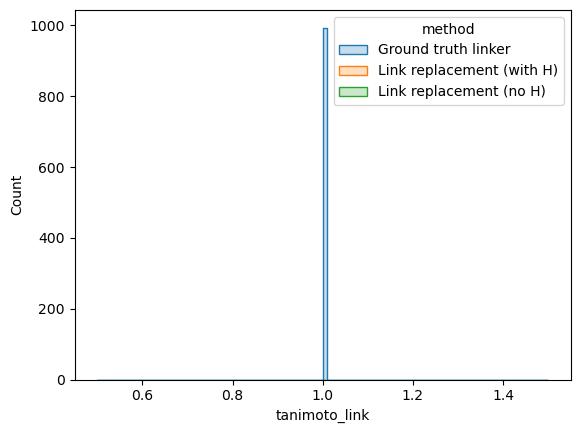

In [29]:
sns.histplot(df, x="tanimoto_link", hue="method", element="step", common_norm=False, bins=100)

In [30]:
# metric = "sucos"
# name = metrics[metric]

# g = sns.FacetGrid(df, col="comparison", hue="method", height=5, aspect=1.3)
# g.map(
#     sns.histplot,
#     metric,
#     bins=50,
#     common_norm=False,
#     stat="density",
#     element="step",
#     # kde=True,
#     fill=False,
# )
# g.add_legend()

In [31]:
# metric = "tanimoto"
# name = metrics[metric]

# g = sns.FacetGrid(df, col="comparison", hue="method", height=5, aspect=1.3)
# g.map(
#     sns.histplot,
#     metric,
#     bins=50,
#     common_norm=False,
#     stat="density",
#     element="step",
#     # kde=True,
#     fill=False,
# )
# g.add_legend()

In [32]:
# g = sns.FacetGrid(df, col="method", row="comparison", height=3, aspect=1.3)
# g.map(sns.kdeplot, "num_atoms_cond", "num_atoms_pred")